# EDA — Caracterização da classe `mercado` (FolhaUOL)

Notebook adaptador da decisão [002 — Plano de EDA](../../docs/decisoes/002-plano-eda.md) e da decisão [003 — Cobertura temporal](../../docs/decisoes/003-cobertura-temporal.md), consumindo o dataset validado pela decisão [001 — Aquisição do dataset](../../docs/decisoes/001-aquisicao-dataset.md).

Toda a lógica científica vive em `src/eda/`. Este notebook apenas:

1. Resolve caminhos (variáveis de ambiente, compatível com Colab).
2. Invoca a função de execução da seção em `scripts/executar_eda_secao.py`.
3. Exibe tabelas e figuras.

Estado atual: **§1 a §8 ativas**. §6 cobre co-ocorrência lexical (TF-IDF + Jaccard); §7 cobre duplicatas exatas e near-duplicates (MinHash/LSH); §8 cobre deriva mínima de vocabulário por trimestre.

In [1]:
import os
import sys
from pathlib import Path

RAIZ_PROJETO = Path.cwd()
while not (RAIZ_PROJETO / "CLAUDE.md").exists() and RAIZ_PROJETO != RAIZ_PROJETO.parent:
    RAIZ_PROJETO = RAIZ_PROJETO.parent
sys.path.insert(0, str(RAIZ_PROJETO))

CAMINHO_CSV = Path(os.environ.get("CAMINHO_CSV", RAIZ_PROJETO / "data" / "raw" / "articles.csv"))
DIRETORIO_ARTEFATOS = Path(os.environ.get("DIRETORIO_ARTEFATOS", RAIZ_PROJETO / "artifacts" / "eda"))

assert CAMINHO_CSV.exists(), f"CSV ausente em {CAMINHO_CSV}. Rode scripts/verificar_dataset.py --extrair."
print(f"CSV:        {CAMINHO_CSV}")
print(f"Artefatos:  {DIRETORIO_ARTEFATOS}")

CSV:        /home/diacrono/Documentos/repositorios/ptbr-market-classification/data/raw/articles.csv
Artefatos:  /home/diacrono/Documentos/repositorios/ptbr-market-classification/artifacts/eda


## §1 — Volume e prevalência global

Total de linhas, nulos por coluna, `value_counts(category)` com política top-7 + `outras`, prevalência global de `mercado` com IC 95% de Wilson.

,total_linhas,positivos_mercado,prevalencia,wilson_ic95_inf,wilson_ic95_sup,linhas_com_category_nula,linhas_com_date_nula
0,167053,20970,0.125529,0.123949,0.127126,0,0


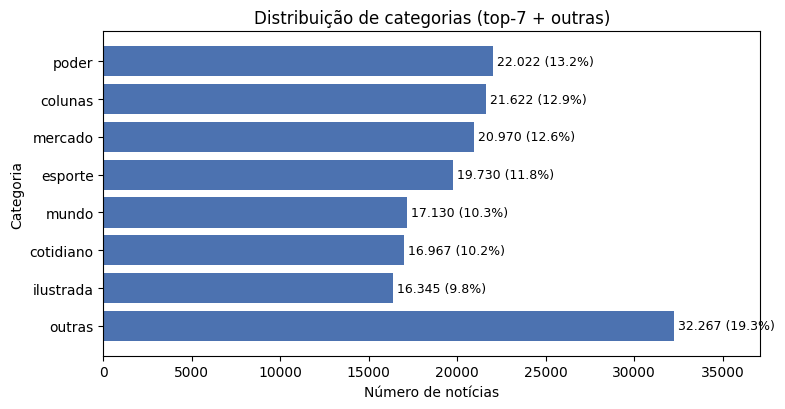

In [2]:
from scripts.executar_eda_secao import executar_secao_1

resultado_1 = executar_secao_1(CAMINHO_CSV, DIRETORIO_ARTEFATOS)
resultado_1["tabela_prevalencia_global"]

In [3]:
resultado_1["tabela_cardinalidades_nulos"]

,coluna,nulos,pct_nulos,valores_unicos_nao_nulos,dtype
0,title,0,0.000000,164119,object
1,text,765,0.004579,165901,object
2,date,0,0.000000,987,datetime64[ns]
3,category,0,0.000000,48,object
4,subcategory,137418,0.822601,293,object
5,link,0,0.000000,167053,object


In [4]:
resultado_1["tabela_top7"]

,categoria,contagem,pct
0,poder,22022,0.131826
1,colunas,21622,0.129432
2,mercado,20970,0.125529
3,esporte,19730,0.118106
4,mundo,17130,0.102542
5,cotidiano,16967,0.101567
6,ilustrada,16345,0.097843
7,outras,32267,0.193154


## §2 — Série temporal da classe

Agregação mensal (principal); diária e semanal no apêndice.

,data_min,data_max,dias_distintos,dias_calendario,meses_zerados,n_meses_zerados,n_pontos_serie_mensal,cobertura_mensal_efetiva
0,2015-01-01,2017-10-01,987,1005,[],0,33,2015-01 a 2017-09


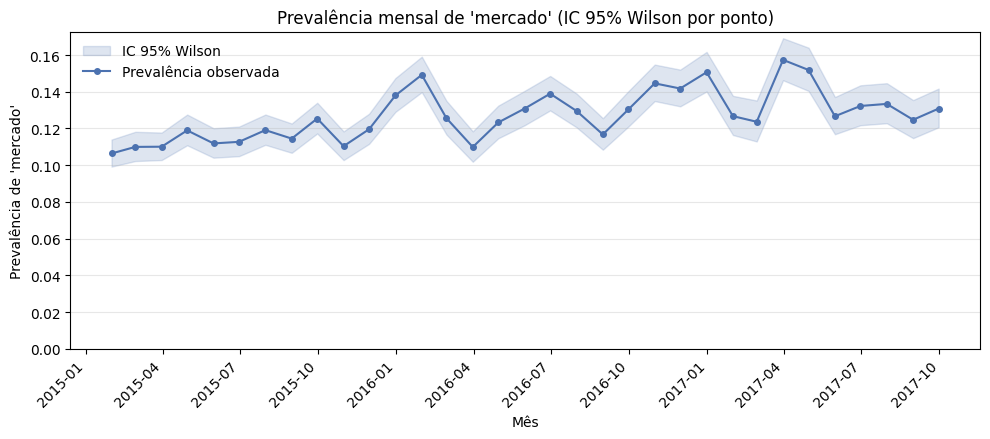

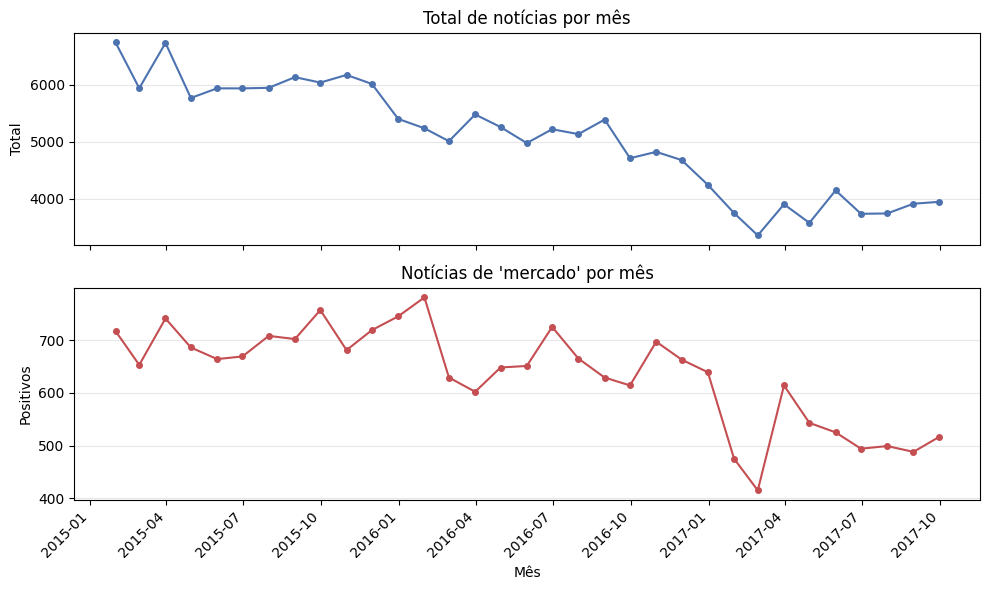

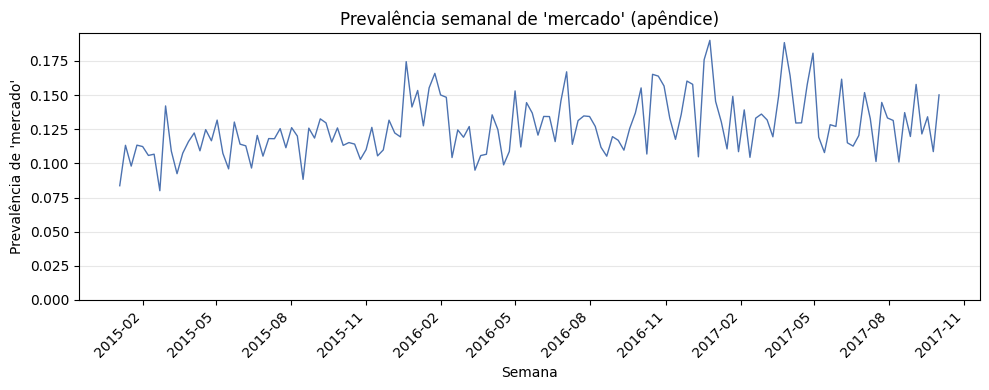

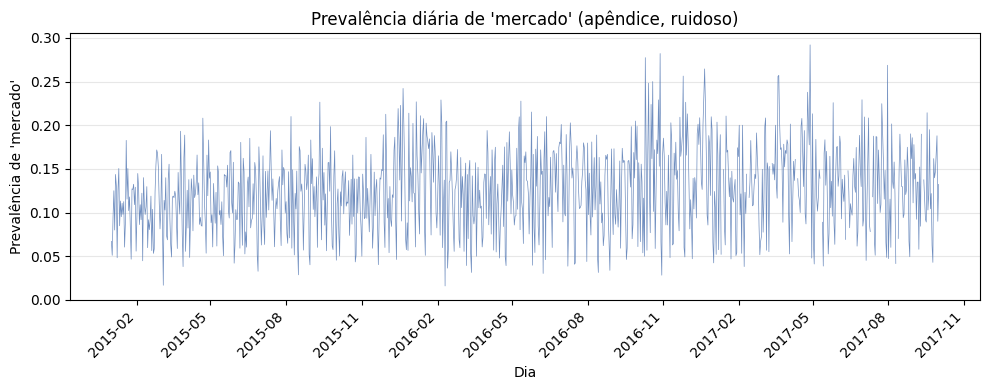

In [5]:
from scripts.executar_eda_secao import executar_secao_2

resultado_2 = executar_secao_2(CAMINHO_CSV, DIRETORIO_ARTEFATOS)
resultado_2["cobertura"]

In [6]:
resultado_2["serie_mensal"].describe().loc[["min", "max", "mean", "std"]]

,total,positivos,prevalencia
min,3356.000000,415.000000,0.106396
max,6739.000000,781.000000,0.157355
mean,5058.545455,634.969697,0.127150
std,968.093522,92.701633,0.013660


**Cobertura mensal efetiva (decisão 003).** Out/2017 (`2017-10-01`, n=121 notícias) é **excluído** da agregação mensal por representar apenas 1 dia — mantê-lo distorcia a série e ampliava artificialmente o IC Wilson do último ponto. A série mensal agora tem **33 pontos** (2015-01 a 2017-09). Out/2017 permanece no corpus bruto para modelagem supervisionada futura, e as séries diária/semanal seguem sobre todo o intervalo (a lacuna aparece nelas por natureza). `TODO artigo:` incluir nota de rodapé na seção de dados mencionando o truncamento de 2017-10-01 e a lacuna sistemática de 18 dias (11 e 12 de jan–set/2017) do dataset-fonte Kaggle.

## §3 — Testes de deriva

Mann-Kendall primário; Z de proporções e Qui² k×2 secundários.

In [7]:
from scripts.executar_eda_secao import _executar_secao_3_a_partir_de

resultado_3 = _executar_secao_3_a_partir_de(resultado_2, DIRETORIO_ARTEFATOS)
resultado_3["tabela_testes"]

,nome,estatistica,p_valor,efeito
0,mann_kendall,0.496212,2.481747e-05,"{""n"": 33, ""primeiro"": 0.1063956076569224, ""ult..."
1,z_proporcoes,-8.426548,0.000000e+00,"{""p1"": 0.11606676382434625, ""p2"": 0.1341427735..."
2,qui_quadrado_k_por_2,105.920340,9.992874e-24,"{""graus_liberdade"": 2, ""prevalencias_observada..."


In [8]:
resultado_3["tabela_anos"]

,ano,positivos,negativos,total
0,2015,8442,64292,72734
1,2016,7943,52196,60139
2,2017,4585,29595,34180


## §4 — Sazonalidade

Prevalência de `mercado` por dia-da-semana (com IC 95% Wilson por dia) e heatmap mês×ano da prevalência. Rótulos em PT-BR nas figuras (`seg, ter, qua, qui, sex, sáb, dom`); no heatmap, células com menos de 100 notícias no mês entram mascaradas em cinza para sinalizar baixo suporte amostral.

,dia_semana,nome,total,positivos,prevalencia,ic_inf,ic_sup
0,0,seg,23851,3479,0.145864,0.141441,0.150400
1,1,ter,24488,3332,0.136067,0.131829,0.140418
2,2,qua,24542,3379,0.137682,0.133428,0.142050
3,3,qui,25375,3312,0.130522,0.126433,0.134723
4,4,sex,24098,3361,0.139472,0.135156,0.143904
5,5,sáb,20396,1934,0.094823,0.090878,0.098920
6,6,dom,24303,2173,0.089413,0.085890,0.093065


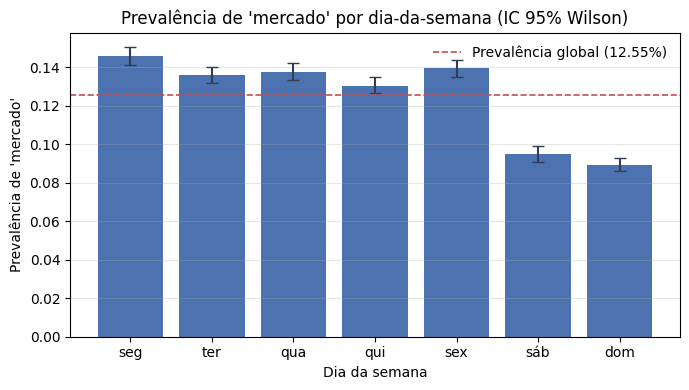

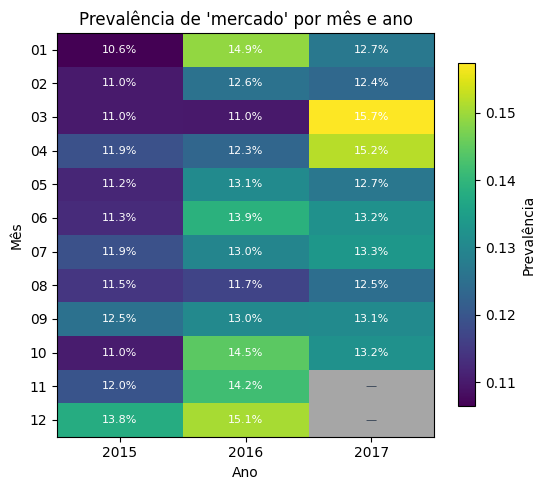

In [9]:
from scripts.executar_eda_secao import executar_secao_4

resultado_4 = executar_secao_4(CAMINHO_CSV, DIRETORIO_ARTEFATOS)
resultado_4["tabela_dia_semana"]

In [10]:
resultado_4["tabela_mes_ano"].head(12)

,ano,mes,total,positivos,prevalencia
0,2015,1,6739,717,0.106396
1,2015,2,5937,653,0.109988
2,2015,3,6731,741,0.110088
3,2015,4,5766,686,0.118973
4,2015,5,5935,664,0.111879
5,2015,6,5934,669,0.112740
6,2015,7,5944,708,0.119112
7,2015,8,6131,702,0.114500
8,2015,9,6036,757,0.125414
9,2015,10,6170,681,0.110373


## §5 — Lacunas e anomalias

Dias de calendário com contagem zero; anomalias `|z|>3` sobre a série diária de contagem total de notícias. Duas regras em colunas separadas — **z clássico** (média, desvio-padrão amostral) e **z robusto** (MAD, com fator 0,6745 para comparabilidade à escala normal). A decisão de qual métrica vai para o artigo fica para ciclo futuro.

Dias de calendário com total == 0: 18


,data,dia_semana
0,2017-01-11,qua
1,2017-01-12,qui
2,2017-02-11,sáb
3,2017-02-12,dom
4,2017-03-11,sáb
5,2017-03-12,dom
6,2017-04-11,ter
7,2017-04-12,qua
8,2017-05-11,qui
9,2017-05-12,sex


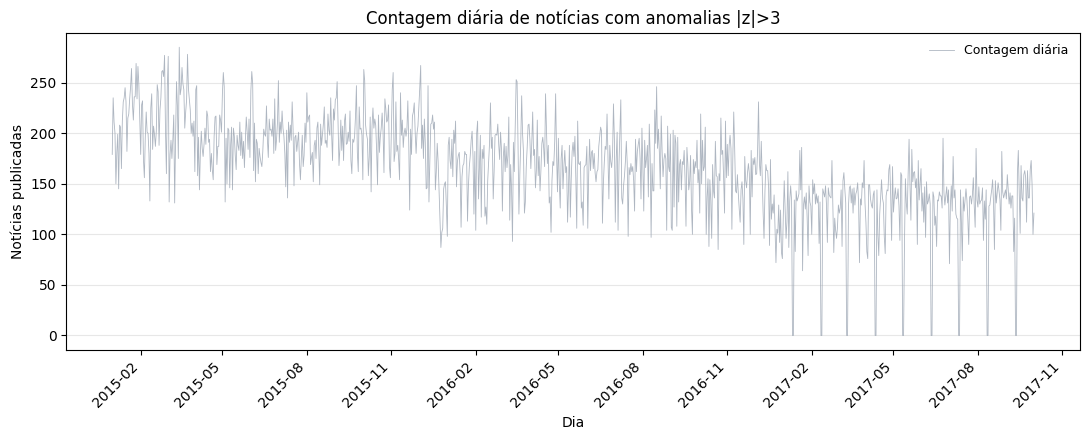

In [11]:
from scripts.executar_eda_secao import executar_secao_5

resultado_5 = executar_secao_5(CAMINHO_CSV, DIRETORIO_ARTEFATOS)
print(f"Dias de calendário com total == 0: {len(resultado_5['dias_zero'])}")
resultado_5["dias_zero"]

In [12]:
anomalias = resultado_5["anomalias"]
n_clas = int(anomalias['flag_classico'].sum()) if not anomalias.empty else 0
n_rob = int(anomalias['flag_robusto'].sum()) if not anomalias.empty else 0
n_ambos = int(anomalias['flag_ambos'].sum()) if not anomalias.empty else 0
print(f"Anomalias flagadas | clássico: {n_clas} | robusto: {n_rob} | ambos: {n_ambos}")
anomalias.head(10)

Anomalias flagadas | clássico: 0 | robusto: 0 | ambos: 0


,data,total,z_classico,z_robusto,flag_classico,flag_robusto,flag_ambos


## §6 — Co-ocorrência lexical entre `mercado` e top-7

TF-IDF por categoria sobre **amostra estratificada determinística** de até 2.000 notícias por categoria (`random_state=SEED`). Stopwords PT-BR do NLTK, `token_pattern=(?u)\b[a-zá-ú]{3,}\b`, `max_df=0.95`, `min_df=2`, `ngram_range=(1,1)`. Extrai top-30 tokens por categoria e mede Jaccard / interseção contra o top-30 de `mercado`. As 8 categorias analisadas são `mercado` + as 7 maiores categorias diferentes de `mercado` (identificadas programaticamente).

Categorias analisadas: ['mercado', 'poder', 'colunas', 'esporte', 'mundo', 'cotidiano', 'ilustrada', 'opiniao']


,categoria_vs,jaccard_top30,tokens_compartilhados
0,mundo,0.176471,acordo;disse;feira;governo;nesta;país;presiden...
1,colunas,0.153846,ainda;ano;brasil;governo;milhões;país;presiden...
2,opiniao,0.153846,ainda;ano;brasil;governo;maior;país;presidente...
3,poder,0.111111,disse;governo;petrobras;presidente;segundo;sobre
4,cotidiano,0.090909,ainda;ano;disse;feira;segundo
5,esporte,0.052632,brasil;disse;feira
6,ilustrada,0.034483,brasil;sobre


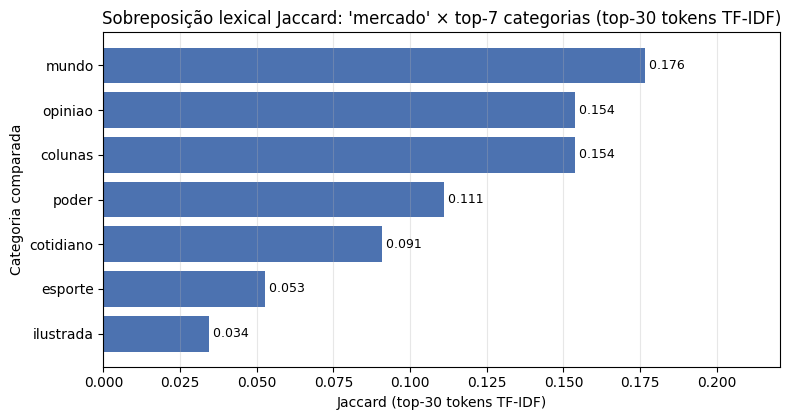

In [13]:
from scripts.executar_eda_secao import executar_secao_6

resultado_6 = executar_secao_6(CAMINHO_CSV, DIRETORIO_ARTEFATOS)
print("Categorias analisadas:", resultado_6["categorias_analisadas"])
resultado_6["sobreposicao"][["categoria_vs", "jaccard_top30", "tokens_compartilhados"]]

In [ ]:
# Top-10 tokens TF-IDF de cada categoria (para leitura rápida).
top_por_categoria = (
    resultado_6["top_tokens"]
    .loc[resultado_6["top_tokens"]["rank"] <= 10]
    .pivot(index="rank", columns="categoria", values="token")
)
top_por_categoria

categoria,colunas,cotidiano,esporte,ilustrada,mercado,mundo,opiniao,poder
rank,,,,,,,,
1,rarará,paulo,time,filme,bilhões,trump,governo,presidente
2,brasil,polícia,clube,anos,ano,disse,brasil,dilma
3,governo,segundo,jogo,cinema,governo,presidente,país,cunha
4,ano,água,jogos,música,mercado,governo,grupofolha,pmdb
5,anos,cidade,corinthians,festival,banco,país,basta,governo
6,vai,prefeitura,partida,diz,empresa,pessoas,presidente,temer
7,dilma,região,copa,sobre,juros,eua,debates,federal
8,coluna,zona,equipe,the,empresas,obama,participação,câmara
9,presidente,rio,futebol,banda,brasil,países,colaborar,disse


: 

## §7 — Duplicatas e near-duplicates

Exatas em `link`, `title`, `text` (denominador = corpus bruto de 167.053 linhas). Near-duplicates via MinHash/LSH (`num_perm=128`, `threshold=0.85`) sobre shingles de caracteres (`k=5`) do campo `text` normalizado (lower + colapso de whitespace).

Linhas com `text` nulo (n=765) são descartadas só na §7 e §8 — o corpus bruto segue completo. **Gatilho de parada** (plano 002): se duplicatas exatas + near afetarem > 1% do corpus, §8 é pulada e a política de deduplicação vira um sub-ciclo com o usuário antes de continuar.

In [ ]:
from scripts.executar_eda_secao import executar_secao_7

resultado_7 = executar_secao_7(CAMINHO_CSV, DIRETORIO_ARTEFATOS)
resultado_7["resumo_exatas"][["tipo", "linhas_duplicadas", "grupos", "pct_corpus"]]

[§7] corpus bruto: 167.053 linhas; após remover text nulo: 166.288
[§7] construindo MinHashes para 166.288 linhas...


In [ ]:
resumo_dedupe = resultado_7["resumo_dedupe"].iloc[0]
pct = resumo_dedupe["pct_corpus_afetado"]
print(f"Linhas com text nulo (descartadas só em §7/§8): {resumo_dedupe['linhas_com_text_nulo']}")
print(f"Afetadas por duplicatas exatas:   {resumo_dedupe['afetadas_exatas']}")
print(f"Afetadas por near-duplicates:     {resumo_dedupe['afetadas_near']}")
print(f"União (afetadas):                 {resumo_dedupe['afetadas_uniao']}  ({pct:.3%})")
print(f"Pares near encontrados:           {resumo_dedupe['pares_near_encontrados']}")
print(f"Pares inter-período (>30 dias):   {resumo_dedupe['pares_inter_periodo']}")
print(f"Parada acionada (>1%)?            {resumo_dedupe['parada_acionada']}")

## §8 — Deriva mínima de vocabulário

Por trimestre calendário, sobre notícias `mercado` com `text` não-nulo: comprimento médio de `title` e `text` (chars e tokens); Jaccard top-50 entre trimestres consecutivos; PSI sobre bag-of-top-200-tokens (baseline = trimestre mais antigo). Linhas de referência na figura de PSI: 0,10 (deriva leve) e 0,25 (deriva forte) — cortes usuais na literatura de *population stability*.

**Só executa se §7 não disparar parada.** Caso disparada, a célula de execução exibe uma mensagem de espera por decisão de deduplicação.

In [ ]:
if resultado_7["parada_acionada"]:
    print(
        "§8 suspensa: §7 disparou parada (>1% do corpus afetado). "
        "Aguardar decisão do usuário sobre política de deduplicação."
    )
    resultado_8 = None
else:
    from scripts.executar_eda_secao import executar_secao_8

    resultado_8 = executar_secao_8(CAMINHO_CSV, DIRETORIO_ARTEFATOS)
    display(resultado_8["estatisticas"])
    display(resultado_8["jaccard"])
    display(resultado_8["psi"])